In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [2]:
# 데이터 가져오기

path = './file/diabetes.csv'
df = pd.read_csv(path)

# 데이터프레임 출력
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [3]:
# 데이터프레임 확인

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [5]:
# 3. 기초 통계량 확인
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [6]:
# 컬럼명 목록 확인
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [7]:
# 결측치 확인
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
# 데이터 타입 확인
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [9]:
# 데이터프레임의 크기 (행, 열 수)
print(df.shape)

(768, 9)


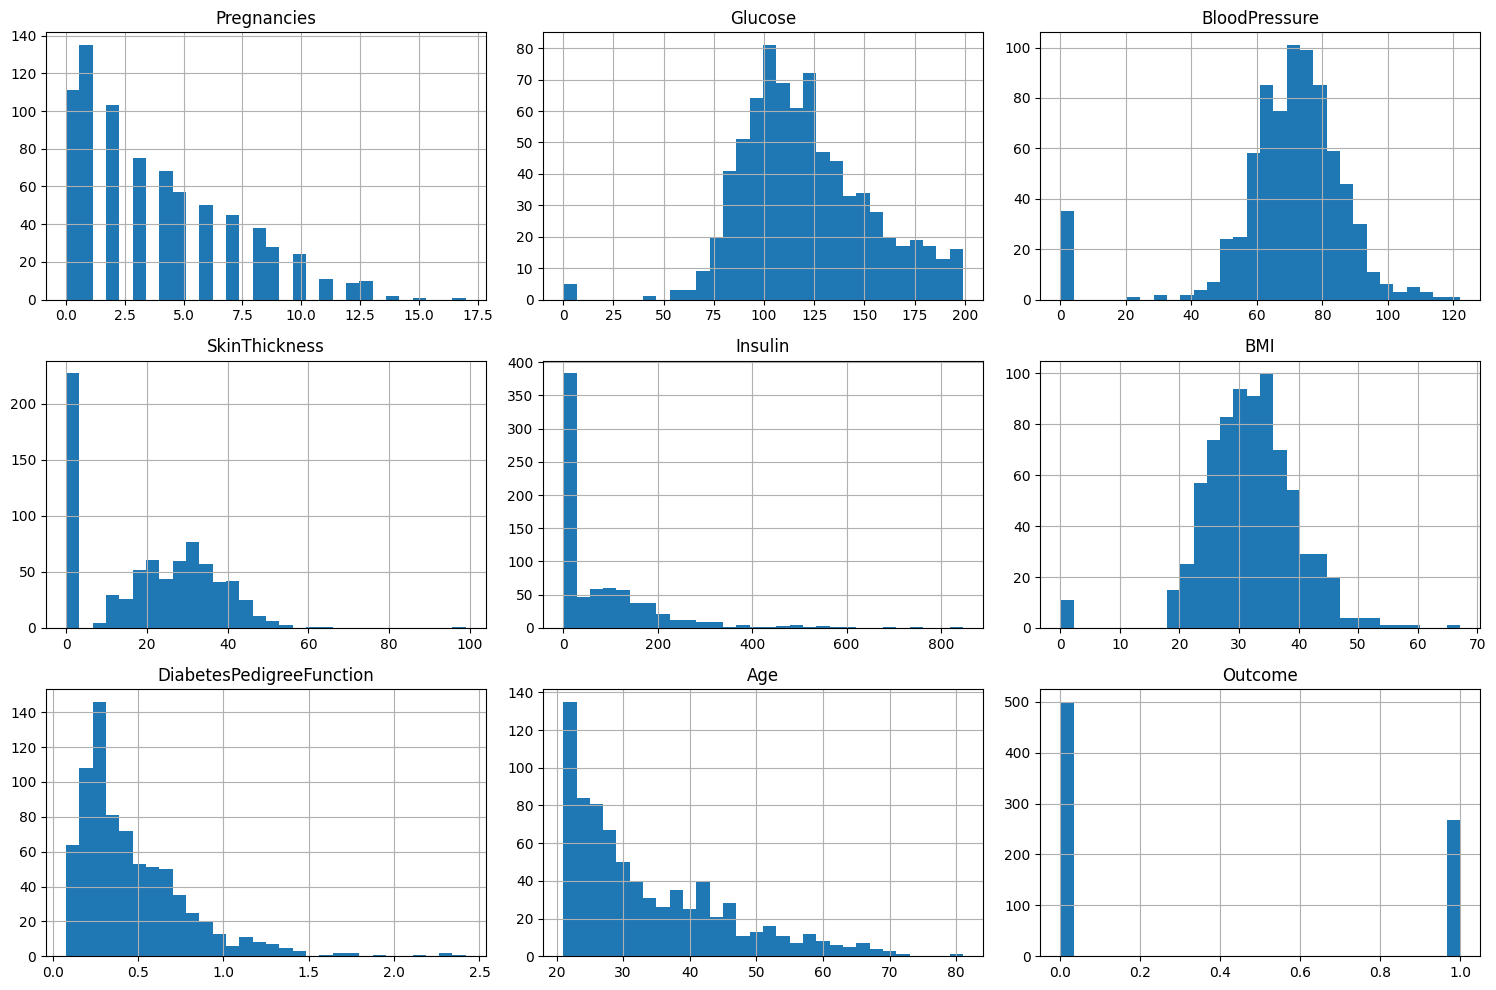

In [10]:
# 히스토그램

df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

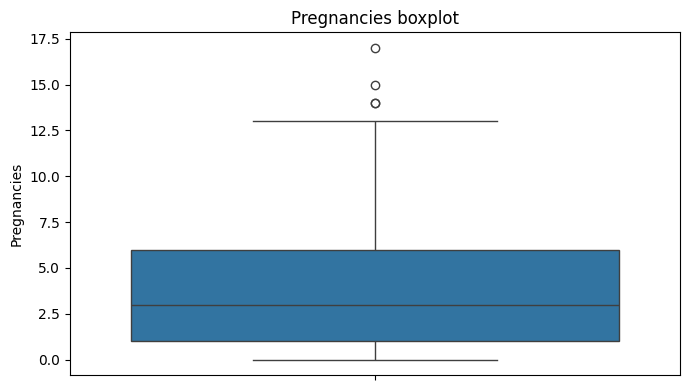

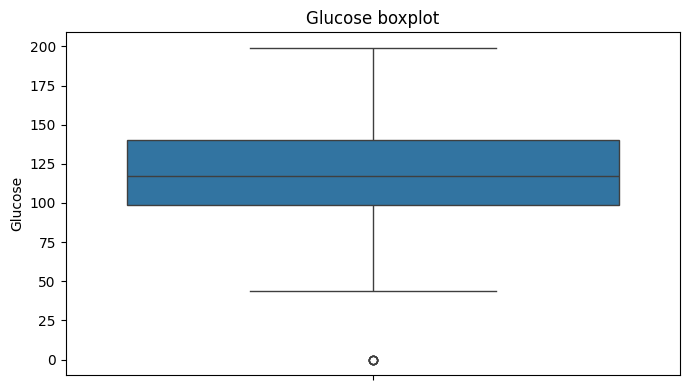

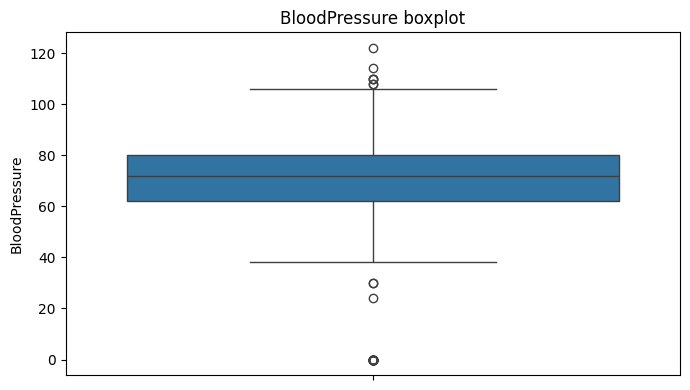

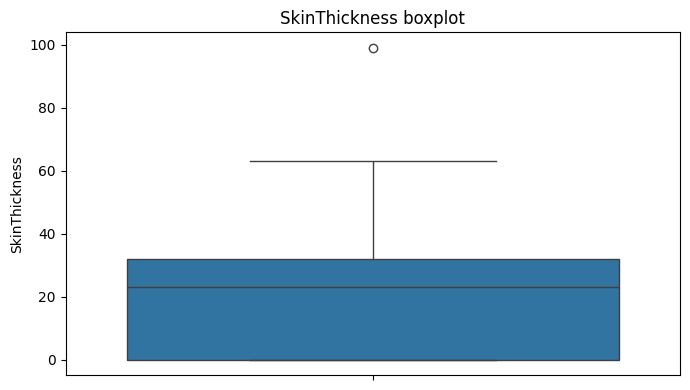

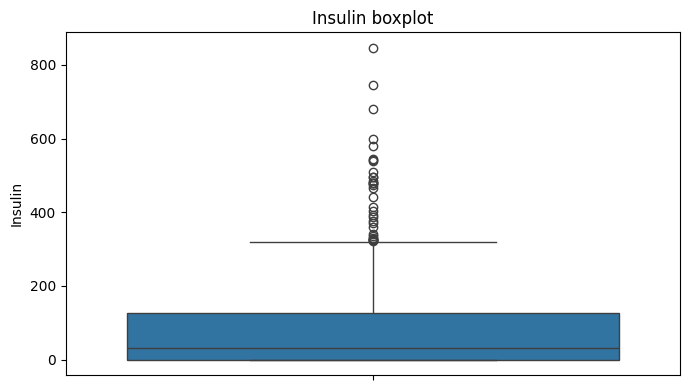

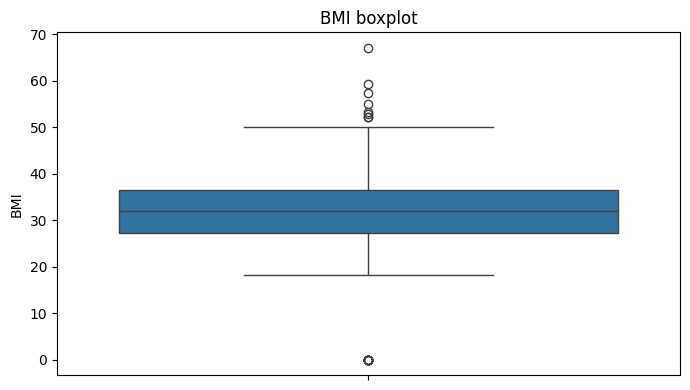

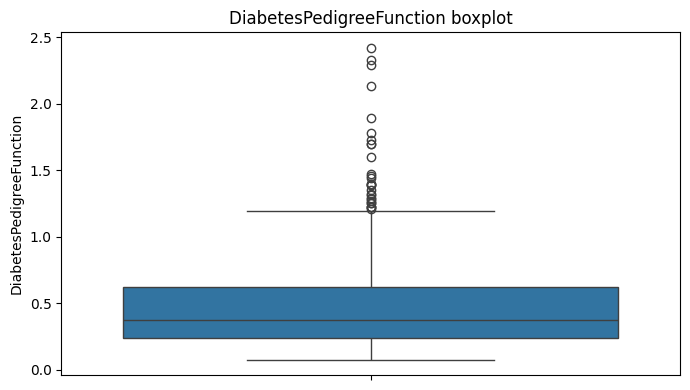

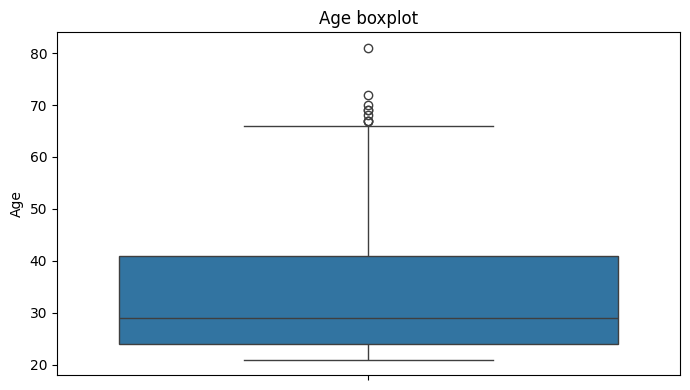

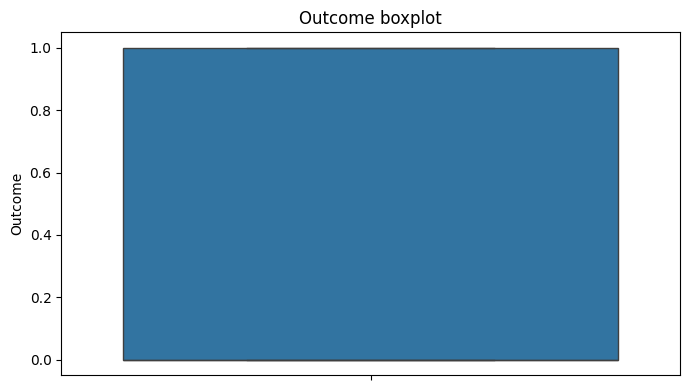

In [11]:
# 이상치 탐지
cols_lst = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 박스플롯으로 시각화
for col in cols_lst:
    plt.figure(figsize=(7, 4))
    sns.boxplot(y=df[col])
    plt.title(f'{col} boxplot')
    plt.tight_layout()
    plt.show()

In [12]:
"""
0 인값 비율 확인
- Glucose 0은 불가능 -> 중앙값 대체 (비율 적음)
- BloodPressure 0은 불가능 -> 중앙값 대체 (비율 적음)
- SkinThickness 0은 불가능 -> KNN Imputer 대체 (비율 많음)
- Insulin 0은 불가능 -> KNN Imputer 대체 (비율 많음)
- BMI 0은 불가능 -> 중앙값 대체 (비율 적음)
"""

# 0으로 채워진 값의 개수
zero_count = (df == 0).sum()

# 전체 행 개수
total_count = len(df)

# 비율 계산 (%)
zero_ratio = (zero_count / total_count) * 100

# 보기 좋게 정리
zero_ratio_df = pd.DataFrame({
    'Zero Count': zero_count,
    'Zero Ratio (%)': zero_ratio.round(2)
})

print(zero_ratio_df)


                          Zero Count  Zero Ratio (%)
Pregnancies                      111           14.45
Glucose                            5            0.65
BloodPressure                     35            4.56
SkinThickness                    227           29.56
Insulin                          374           48.70
BMI                               11            1.43
DiabetesPedigreeFunction           0            0.00
Age                                0            0.00
Outcome                          500           65.10


In [13]:
# 위의 방법대로 결측값 처리
from sklearn.impute import KNNImputer
import numpy as np

# 0을 NaN으로 변환
cols_with_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero_invalid] = df[cols_with_zero_invalid].replace(0, np.nan)

# 중앙값 대체 (결측률 낮은 컬럼)
for col in ['Glucose', 'BloodPressure', 'BMI']:
    df[col] = df[col].fillna(df[col].median())

# KNN 대체 (결측률 높은 컬럼)
imputer = KNNImputer(n_neighbors=5)
df[['SkinThickness', 'Insulin']] = imputer.fit_transform(df[['SkinThickness', 'Insulin']])

In [14]:
# 결측값 확인
zero_count = (df == 0).sum()

# 전체 행 개수
total_count = len(df)

# 비율 계산 (%)
zero_ratio = (zero_count / total_count) * 100

# 보기 좋게 정리
zero_ratio_df = pd.DataFrame({
    'Zero Count': zero_count,
    'Zero Ratio (%)': zero_ratio.round(2)
})

print(zero_ratio_df)


                          Zero Count  Zero Ratio (%)
Pregnancies                      111           14.45
Glucose                            0            0.00
BloodPressure                      0            0.00
SkinThickness                      0            0.00
Insulin                            0            0.00
BMI                                0            0.00
DiabetesPedigreeFunction           0            0.00
Age                                0            0.00
Outcome                          500           65.10


In [15]:
# 3. 기초 통계량 확인
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.153420  152.443550   
std       3.369578   30.438286      12.096642       8.790942   88.245092   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  103.750000   
50%       3.000000  117.000000      72.000000      29.153420  155.548223   
75%       6.000000  140.250000      80.000000      32.000000  155.548223   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232    0.476951  
min     18.200000                  

In [16]:
# 스케일링 전 데이터가 치우쳐져 있는지 확인하기
# 왜도를 추출했을 때, Insulin, DiabetesPedigreeFunction 컬럼이 치우쳐져 있음
# standard scaler를 적용하기 전 log 스케일링 적용
print(df.skew())

Pregnancies                 0.901674
Glucose                     0.535587
BloodPressure               0.141885
SkinThickness               0.822173
Insulin                     2.799853
BMI                         0.599233
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64


In [17]:
import numpy as np
df['Insulin'] = np.log1p(df['Insulin'])  # 0 포함 시 log1p 사용
df['DiabetesPedigreeFunction'] = np.log1p(df['DiabetesPedigreeFunction'])

In [23]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 22.2 MB/s eta 0:00:00


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

pip = Pipeline([
    ("prep", StandardScaler()),
    ("model", KNeighborsClassifier()),
])

grid_param = [
    # KNN
    {"prep": [StandardScaler()],
     "model": [KNeighborsClassifier()],
     "model__n_neighbors": range(1, 100)},
    
    # GaussianNB
    {"prep": ['passthrough'],  # None → 'passthrough'
     "model": [GaussianNB()]},

    # Decision Tree
    {"prep": ['passthrough'],
     "model": [DecisionTreeClassifier()],
     "model__max_depth": range(1, 40),
     "model__criterion": ['gini', 'entropy']},
    
    # RandomForest 모델 추가
    {"prep": ['passthrough'],
     "model": [RandomForestClassifier(random_state=42)],
     "model__n_estimators": [1, 30, 60, 90, 120, 150, 180],
     "model__criterion": ['gini', 'entropy'],
     "model__max_depth": [3, 5, 10, None]},
    
    # SVC 추가
    {"prep": [StandardScaler()],
    "model": [SVC()],
    "model__C": [0.1, 1, 10],
    "model__kernel": ['linear', 'rbf'],
    "model__gamma": [1,10,100]},
    
    # XGBoost 추가
    {"model": [XGBClassifier(eval_metric='logloss')],
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.3]},
    
    # LightGBM 추가
    {"model": [LGBMClassifier()],
    "model__n_estimators": [50, 100],
    "model__max_depth": [-1, 3, 5],
    "model__learning_rate": [0.01, 0.1]},
    
    # LogisticRegression 
    {"model": [LGBMClassifier(random_state=42)],
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__num_leaves": [15, 31, 63],
    "model__min_child_samples": [10, 20, 30],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]}
]

grid = GridSearchCV(pip, grid_param, cv=5, verbose=-1)
grid.fit(X, y)

Fitting 5 folds for each of 290 candidates, totalling 1450 fits
[CV] END model=KNeighborsClassifier(), model__n_neighbors=1, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=1, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=1, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=1, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=1, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=2, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=2, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=2, prep=StandardScaler(); total time=   0.0s
[CV] END model=KNeighborsClassifier(), model__n_neighbors=2, prep=StandardScaler(); total time=   0.0s
[CV] END 

c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END model=LGBMClassifier(), model__learning_rate=0.01, model__max_depth=3, model__n_estimators=50; total time=   0.0s
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

...

c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 689
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\OSS\.conda\envs\pandas\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 692
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,estimator,Pipeline(step...lassifier())])
,param_grid,"[{'model': [KNeighborsClassifier()], 'model__n_neighbors': range(1, 100), 'prep': [StandardScaler()]}, {'model': [GaussianNB()], 'prep': ['passthrough']}, ...]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [20]:
print("최적 파라미터:", grid.best_params_)
print("최고 평균 정확도:", grid.best_score_)    

최적 파라미터: {'model': KNeighborsClassifier(), 'model__n_neighbors': 19, 'prep': StandardScaler()}
최고 평균 정확도: 0.7734912146676851
